In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import datasets, layers, models

2026-06-05 16:40:30.285407: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780677630.489400      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780677630.542356      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780677630.984437      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780677630.984470      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780677630.984473      23 computation_placer.cc:177] computation placer alr

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 46s 0us/step


In [3]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

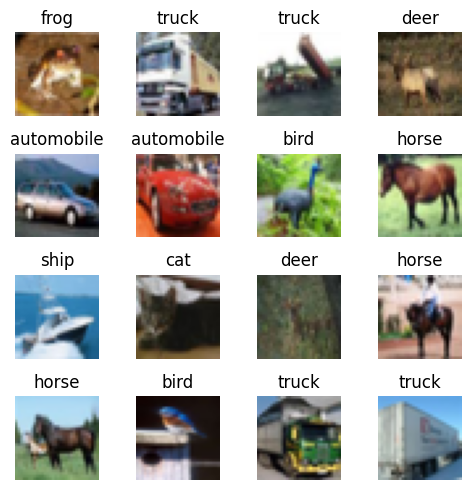

In [4]:
#plot dataset
plt.figure(figsize=(5, 5))
for i in range (16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_train[i])
    plt.title(classes[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## from video

In [5]:
print('x train shape:', x_train.shape)
print('x test shape:', x_test.shape)
print('y train shape:', y_train.shape)
print('y test shape:', x_test.shape)

x train shape: (50000, 32, 32, 3)
x test shape: (10000, 32, 32, 3)
y train shape: (50000, 1)
y test shape: (10000, 32, 32, 3)


In [6]:
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)
#reshape target into 1D array

print('y train shape:', y_train.shape)
print('y test shape:', x_test.shape)

y train shape: (50000,)
y test shape: (10000, 32, 32, 3)


In [7]:
#normalize data (divide each by 255 bcs scale RGB is from 0-255)
x_train = x_train / 255.0
x_test = x_test / 255.0

In [8]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780677694.131730      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [9]:
#compile
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#train
history = cnn.fit(
    x_train,
    y_train,
    epochs=10
)

Epoch 1/10


I0000 00:00:1780677698.409958      68 service.cc:152] XLA service 0x781f3400a510 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780677698.409989      68 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780677698.701581      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


  59/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1285 - loss: 2.2754

I0000 00:00:1780677700.572528      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.4690 - loss: 1.4749
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6060 - loss: 1.1249
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6528 - loss: 0.9917
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6862 - loss: 0.9082
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7069 - loss: 0.8445
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7261 - loss: 0.7889
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7394 - loss: 0.7509
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7537 - loss: 0.7119
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7650 - loss: 0.6734
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7772 - loss: 0.6396


based on the vid, they dont use any validation set

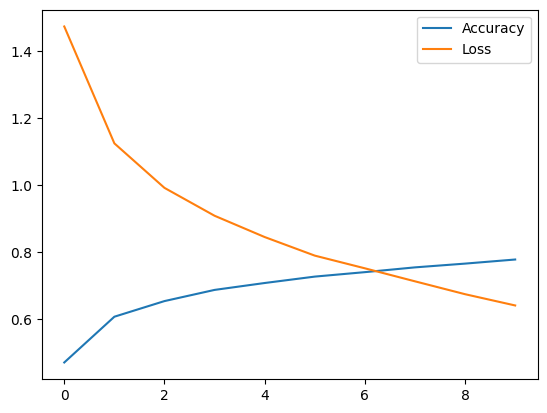

In [10]:
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['loss'],label='Loss')
plt.legend()

In [11]:
cnn.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6882 - loss: 0.9399


[0.9398510456085205, 0.6881999969482422]

In [12]:
y_pred = cnn.predict(x_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.73      0.74      0.74      1000
           1       0.75      0.88      0.81      1000
           2       0.60      0.58      0.59      1000
           3       0.54      0.44      0.49      1000
           4       0.65      0.64      0.65      1000
           5       0.47      0.75      0.58      1000
           6       0.82      0.71      0.76      1000
           7       0.83      0.65      0.73      1000
           8       0.82      0.78      0.80      1000
           9       0.83      0.71      0.76      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



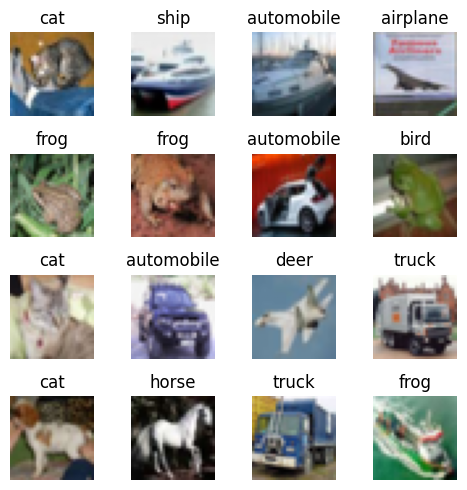

In [13]:
#plot classification
plt.figure(figsize=(5, 5))
for i in range (16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_test[i])
    plt.title(classes[y_pred_classes[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## tuning to make higher acc

In [14]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    # layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    # layers.Dropout(0.25),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


split training into validation set

In [15]:
#compile
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#add earlystop
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5,        
    restore_best_weights=True 
)

#train
history = cnn.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=128,
    # callbacks=[early_stop],
    validation_split=0.1
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.2992 - loss: 2.2275 - val_accuracy: 0.2582 - val_loss: 1.9781
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4183 - loss: 1.6992 - val_accuracy: 0.5180 - val_loss: 1.3549
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4760 - loss: 1.4912 - val_accuracy: 0.5638 - val_loss: 1.2446
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5224 - loss: 1.3565 - val_accuracy: 0.5952 - val_loss: 1.1466
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5558 - loss: 1.2631 - val_accuracy: 0.6112 - val_loss: 1.1325
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5801 - loss: 1.1976 - val_accuracy: 0.6294 - val_loss: 1.0665
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6019 - loss: 1.1417 - val_accuracy: 0.6548 - val_loss: 1.0054
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6179 - loss: 1.0934 - val_accuracy: 

acc improved bcs fixing the target label scale allowed the loss func correctly calculate gradients, so it update the weights and model can learn more

adding more epoch for CNN increases the acc

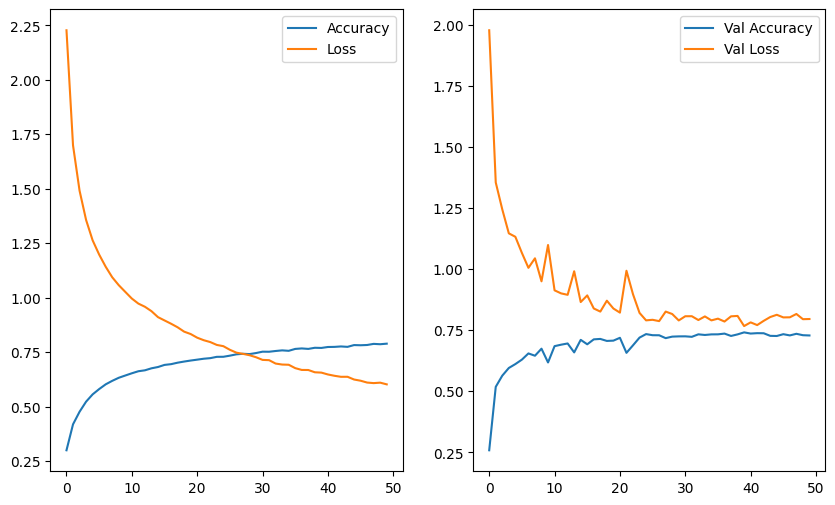

In [16]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['loss'],label='Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'],label='Val Accuracy')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.legend()

In [17]:
cnn.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7212 - loss: 0.8230


[0.822968065738678, 0.7211999893188477]

In [18]:
y_pred = cnn.predict(x_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.75      0.78      0.77      1000
           1       0.86      0.83      0.85      1000
           2       0.58      0.68      0.62      1000
           3       0.49      0.59      0.54      1000
           4       0.82      0.51      0.63      1000
           5       0.57      0.70      0.63      1000
           6       0.83      0.73      0.78      1000
           7       0.80      0.75      0.77      1000
           8       0.84      0.83      0.84      1000
           9       0.83      0.80      0.82      1000

    accuracy                           0.72     10000
   macro avg       0.74      0.72      0.72     10000
weighted avg       0.74      0.72      0.72     10000



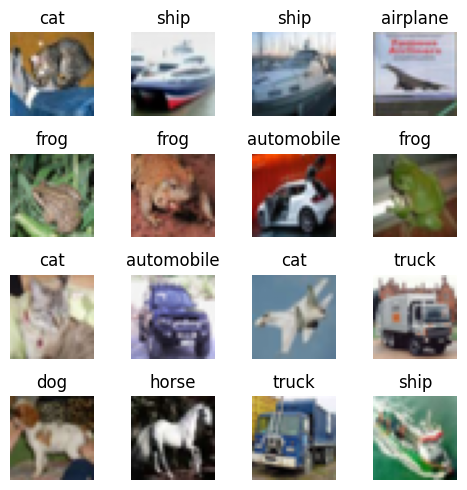

In [19]:
#plot classification
plt.figure(figsize=(5, 5))
for i in range (16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_test[i])
    plt.title(classes[y_pred_classes[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()